### __`Combinaison réduction de dimension + semi-supervision`__

Nous allons appliquer une réduction de dimension avant de faire la classification en semi-supervisé sur fashion mnist. Nous utiliserons Umap mais vous pouvez aussi comparer à d'autres méthodes (t-sne par exemple)

In [1]:
%pip -q install umap-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib inline

References: 
   
   - https://umap-learn.readthedocs.io/en/latest/transform.html
   - https://plotly.com/python/t-sne-and-umap-projections/
   - https://pair-code.github.io/understanding-umap/

In [3]:
import umap
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE, MDS
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [7]:
sns.set_theme(context="paper", style="white")
%time mnist = fetch_openml("Fashion-Mnist", version=1) #,return_X_y=True)
#print("\n\n",mnist.DESCR) # type: ignore

CPU times: user 2.42 s, sys: 366 ms, total: 2.79 s
Wall time: 2.97 s


#### `Manifold`
 - En maths, un manifold (variété) est un espace qui, vu de près, ressemble à un espace euclidien classique, même si sa forme globale peut être tordue ou courbée.

`En machine learning, lorsque l'on parle de manifold ou de manifold hypothesis, on veut dire :`
 - les données de hautes dimensions (images, audio, etc.) existent auprès d’une variété de dimension beaucoup plus faible dans cet espace.
 - Beaucoup de méthodes (manifold learning, semi‑supervisé, auto‑encoders) supposent que cette variété est relativement lisse et structurée, ce qui permet de faire de la réduction de dimension et de la propagation de labels plus intelligemment que dans l’espace brut.

#### `Uniform Manifold Approximation and Projection`
- `UMAP est un algorithme de réduction de dimension non linéaire`.
- `UMAP sert à projeter des données de grande dimension vers un espace de faible dimension`
- `Souvent 2D ou 3D en essayant de préserver la structure du manifold sous‑jacent :`     
    - points proches dans l’espace original restent proches dans l’espace réduit, 
    - tout en conservant mieux la structure globale que t‑SNE et en étant plus rapide.
    - Après fit, l’objet possède un attribut embedding_ qui contient la projection (n_samples,n_components).

`Propriétés importantes de l’objet`

L’objet UMAP encapsule notamment :
- Les hyperparamètres : 
   - _`n_neighbors :`_ 
      - Nombre de voisins les plus proches utilisés pour construire le graphe de voisinage, 
   - _`min_dist :`_ 
      - Distance minimale autorisée entre deux points dans l’espace de sortie (2D/20D, etc.), 
      - Petit min_dist (proche de 0) → points très serrés, clusters compacts et « clumpés », 
      - bon pour la détection de groupes fins ; 
      - grand min_dist → points plus espacés, 
      - topologie globale mieux préservée mais moins de densification locale
   - _`metric`_, 
     - Fonction de distance utilisée en entrée pour mesurer la similarité entre deux échantillons
     - Par défaut metric='euclidean', UMAP supporte (manhattan, cosine, minkowski, canberra, etc.) 
     - Le choix doit être cohérent avec la géométrie de tes données.
   - _`n_components`_
     - le nombre de dimension de la projection, 
     - peux être ajusté à n’importe quel entier (typiquement 2–100) 
     - si on veut un espace latent de dimension plus élevée pour du clustering, de la classification 
     - ou comme entrée d’un autre modèle (par exemple 20D pour ton LabelPropagation).
   - etc.
- Le graphe de proximité appris sur les données originales.
- L’embedding final (embedding_) et 
- La possibilité de transformer de nouveaux points dans le même espace réduit 
- Cette propriété est utile pour du metric learning ou de la visualisation interactive.


In [8]:
subset_size = 10000
X = mnist.data[:subset_size] # type: ignore
y = mnist.target[:subset_size] # type: ignore

print("nb de dimension de mnist :", X.shape)        # (70000, 784)
print("nb d'exemples :", X.shape[0])
print("dimension     :", X.shape[1])

nb de dimension de mnist : (10000, 784)
nb d'exemples : 10000
dimension     : 784


In [9]:
subset_ratio = 0.30 # on ne prend pas tout pour aller plus vite
train_ratio = 0.9  # on entraine sur % du subset
labelled_ratio = 0.1 # et on utilise qu'une partie des labels (semi-sup)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=0, 
    train_size=train_ratio*subset_ratio, 
    test_size=(1-train_ratio)*subset_ratio
    )
print(f"len train {len(X_train)} len test {len(X_test)}")

len train 2700 len test 300


`L'algorithme UMAP de réduction de dimension non linéaire, projete les données mnist de grande dimension vers un espace de faible dimension 2D en essayant de préserver la structure du manifold sous‑jacent.`

In [8]:
import umap
reducer = umap.UMAP(
     n_neighbors=15, n_components=2, metric='euclidean', n_epochs=None, learning_rate=1.0,
     init='spectral', min_dist=0.1, spread=1.0, set_op_mix_ratio=1.0, local_connectivity=1.0, 
     repulsion_strength=1.0, negative_sample_rate=5, transform_queue_size=4.0, a=None, b=None, 
     random_state=None, metric_kwds=None, angular_rp_forest=False, target_n_neighbors=-1,
     target_metric='categorical', target_metric_kwds=None, target_weight=0.5, transform_seed=42, verbose=False)

In [9]:
subset_size = 10000
print("len mnist : ",len(mnist.data))# type: ignore
%time embedding1 = reducer.fit_transform(X)
print("Taille de la nouvelle dimension : ",embedding1.shape) # type: ignore
print("Taille du nombre d'éléments : ",embedding1.size) # type: ignore      

len mnist :  70000
CPU times: user 52.9 s, sys: 933 ms, total: 53.8 s
Wall time: 16.1 s
Taille de la nouvelle dimension :  (10000, 2)
Taille du nombre d'éléments :  20000


##### `Construction des labels de couleur`
- Ce code simule un scénario semi‑supervisé en masquant aléatoirement une partie des labels. 
- Il tire aléatoirement 70% des indices parmi tous les points, et on met leurs labels à -1.
- On les garde tous mais, sans se servir de la classe pour la partie supervisée / metric learning. 

In [10]:
# data = mnist.data
color = mnist.target[:subset_size].astype(int) # type: ignore
# dont show label randomly for X% of points
chosen_idx = np.random.choice(subset_size, replace = False, size = int(0.7*subset_size))
color[chosen_idx] = -1


`Concrètement :`
 - On garde les embeddings UMAP pour les 10 000 digits.
 - On indique à l’algorithme que seulement 30% des points ont un label fiable; 
 - Les autres sont traités comme non labellisés grâce à la valeur spéciale -1.

#### `Visualisation de l’embedding UMAP`

- On affiche les points MNIST projetés en 2D par UMAP, 
- Seuls 30% ont une couleur correspondant à leur vrai label, 
- Les autres étant marqués par la valeur -1 sont masqués ou « unlabelled » dans la visualisation.

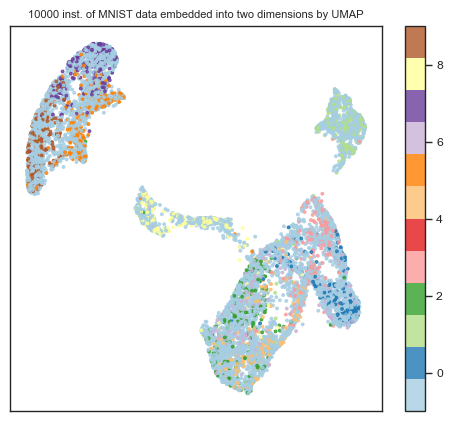

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
plt.scatter(embedding1[:, 0], embedding1[:, 1], c=color, cmap = "Paired", s=4, alpha=0.8) # type: ignore
plt.setp(ax, xticks=[], yticks=[])
plt.title(f"{len(embedding1)} inst. of MNIST data embedded into two dimensions by UMAP", fontsize=8) # type: ignore
plt.colorbar()
plt.show()

### `Exercice` 

sur le modèle du notebook avec Selftraining / Labelpropagation

- entrainez un modèle de K plus proches voisins sur la projection faite par UMAP
- appliquer le selftraining ou une propagation de labels

`Pipeline conceptuel`

__On part de X, y (MNIST)__
 - choisir un subset si besoin, 
 - faire un split train/test : X_train, X_test, y_train, y_test.
 - on apprend UMAP sur X_train, puis tu transformes train et test :
 - Z_train = UMAP().fit_transform(X_train)
 - Z_test = UMAP().transform(X_test)

On crée y_labelled à partir de y_train (avec -1 pour les non‑labellés).
On applique self‑training sur (Z_train, y_labelled) et tu évalues sur (Z_test, y_test).
UMAP sert à aplatir la variété en une représentation plus « géométriquement propre » pour les KNN / SelfTrainingClassifier.

In [11]:
subset_ratio = 0.30 # on ne prend pas tout pour aller plus vite
train_ratio = 0.9  # on entraine sur % du subset
labelled_ratio = 0.1 # et on utilise qu'une partie des labels (semi-sup)

subset_size = 10000
X = mnist.data[:subset_size] # type: ignore
y = mnist.target[:subset_size] # type: ignore

print("nb de dimension de mnist :", X.shape)        # (70000, 784)
print("nb d'exemples :", X.shape[0])
print("dimension     :", X.shape[1])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=0, 
    train_size=train_ratio*subset_ratio, 
    test_size=(1-train_ratio)*subset_ratio
)
print(f"len train {len(X_train)} len test {len(X_test)}")

nb de dimension de mnist : (10000, 784)
nb d'exemples : 10000
dimension     : 784
len train 2700 len test 300


### `Modèle self-trained`
`1. Self‑training simple / itératif`
Utiliser le modèle supervisé comme “Evaluateur” pour s’auto‑alimenter avec des pseudo‑labels prédits.

In [ ]:
path="./imgumap/"

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.semi_supervised import LabelSpreading, LabelPropagation
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import pandas as pds

In [14]:
import os

def display_confusionMatrix(y_test, y_pred, num_classes, out_dir=path, filename="conf_mat.png"):
    y_test = np.asarray(y_test, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    cm = confusion_matrix(y_test, y_pred, labels=np.arange(num_classes))
    os.makedirs(out_dir, exist_ok=True)  # crée le répertoire s'il n'existe pas
    fig, ax = plt.subplots(figsize=(3, 3))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=np.arange(num_classes))
    disp.plot(ax=ax, xticks_rotation="vertical", cmap="Blues", colorbar=False)
    plt.tight_layout()
    out_path = os.path.join(out_dir, filename)
    fig.savefig(out_path, dpi=300, bbox_inches="tight")  # sauvegarde l'image
    plt.close(fig)  # pas d'affichage

In [15]:
def self_trainedModel(X_train,y_labelled,X_test,y_test,n_neighbors=5 ):
    # on compare à entrainement sur la petite base supervisée 
    mask = (y_labelled != -1) 
    modelbase_KNN = KNeighborsClassifier(n_neighbors=n_neighbors)
    modelbase_KNN.fit(X_train[mask],y_labelled[mask])
    y_pred = modelbase_KNN.predict(X_test)
    acc = accuracy_score(y_pred,y_test)
    return modelbase_KNN, y_pred, acc

__Principe (pseudo‑labelling itératif) :__
- Entraîner un modèle supervisé sur les données labellisées uniquement (peu de données labellisées).
- Prédire les labels du non‑labellé, garder seulement les prédictions à forte confiance (ex. proba > 0.9).
- Ajouter ces exemples pseudo‑labellés au jeu de train, réentraîner.
- Répéter 2–3 jusqu’à convergence ou plus rien de suffisamment confiant.

`Caractéristiques :`
- __Mécanisme :__ 
    - Cadre “modèle supervisé avec un jeu de train qui augmente”, l’architecture du modèle ne change pas.
- __Avantages :__ Facile à plugger sur un modèle (CNN, Transformer, etc.). 
    - Peut dépasser nettement le baseline si le modèle de départ est déjà raisonnablement bon.
- __Inconvénients :__ 
    - Risque d’amplifier les erreurs (confirmation biaisée) si les pseudo‑labels sont mauvais. 
    - Sensible aux seuils de confiance, à l’ordre d’ajout des exemples, etc.

In [16]:
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.metrics import accuracy_score

def self_trainedFunction(X_train, y_labelled, X_test, y_test,
                         threshold=0.9, max_iter=None,n_neighbors=5):
    # API récente : utiliser `estimator=` et non `base_estimator=`
    st = SelfTrainingClassifier(
            KNeighborsClassifier(n_neighbors=n_neighbors,weights="distance"),
            threshold=threshold,
            criterion="threshold",
            max_iter=max_iter,
            verbose=False
            )
    st.fit(X_train, y_labelled)
    y_pred = st.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return st, y_pred, acc

In [17]:
labelled_ratio = 0.025 # combien d'exemples avec labels ? -> 
y_labelled = np.copy(y_train) # type: ignore
y_labelled[int(labelled_ratio*len(y_labelled)):] = -1 # type: ignore
num_classes = np.unique(np.asarray(y_labelled, dtype=int), return_counts=True)[0].size - 1

print(f"nombre d'items total {len(y_labelled)}") 
print(f"labellisé : {int(labelled_ratio*len(y_labelled))}") # type: ignore
print(f" unlabellisés {len(y_labelled)-int(labelled_ratio*len(y_labelled))} ") # type: ignore
print(f"nombre de classes {num_classes}")

nombre d'items total 2700
labellisé : 67
 unlabellisés 2633 
nombre de classes 10


In [18]:
reducer = umap.UMAP(
     n_neighbors=15, n_components=2, metric='euclidean', n_epochs=None, learning_rate=0.2,
     init='spectral', min_dist=0.01, spread=1.0, set_op_mix_ratio=1.0, local_connectivity=1.0, 
     repulsion_strength=1.0, negative_sample_rate=2, transform_queue_size=4.0, a=None, b=None, 
     random_state=None, metric_kwds=None, angular_rp_forest=False, target_n_neighbors=-1,
     target_metric='categorical', target_metric_kwds=None, target_weight=0.0, transform_seed=42, verbose=False)

Z_train = reducer.fit_transform(X_train)
Z_test = reducer.transform(X_test)

accuracy 0.7433


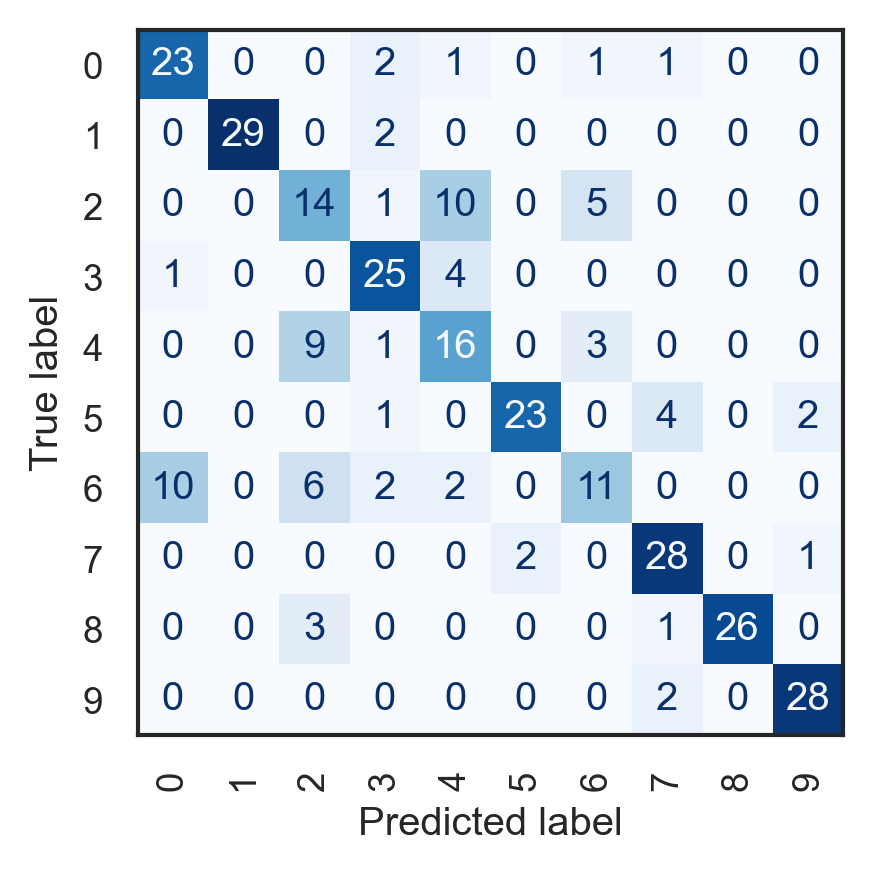

In [20]:
modelbase_KNN, y_pred, acc = self_trainedModel(Z_train,y_train,Z_test,y_test,n_neighbors=15 )

print(f"accuracy {acc:.4f}")
filename="cnfmatKNNSelftTrng.png"
display_confusionMatrix(y_test,y_pred,num_classes,filename=filename)
from IPython.display import Image, display
display(Image(os.path.join(path, filename), width=300))

Self-training sur UMAP : 0.6100
n_iter_ = 1 term = all_labeled


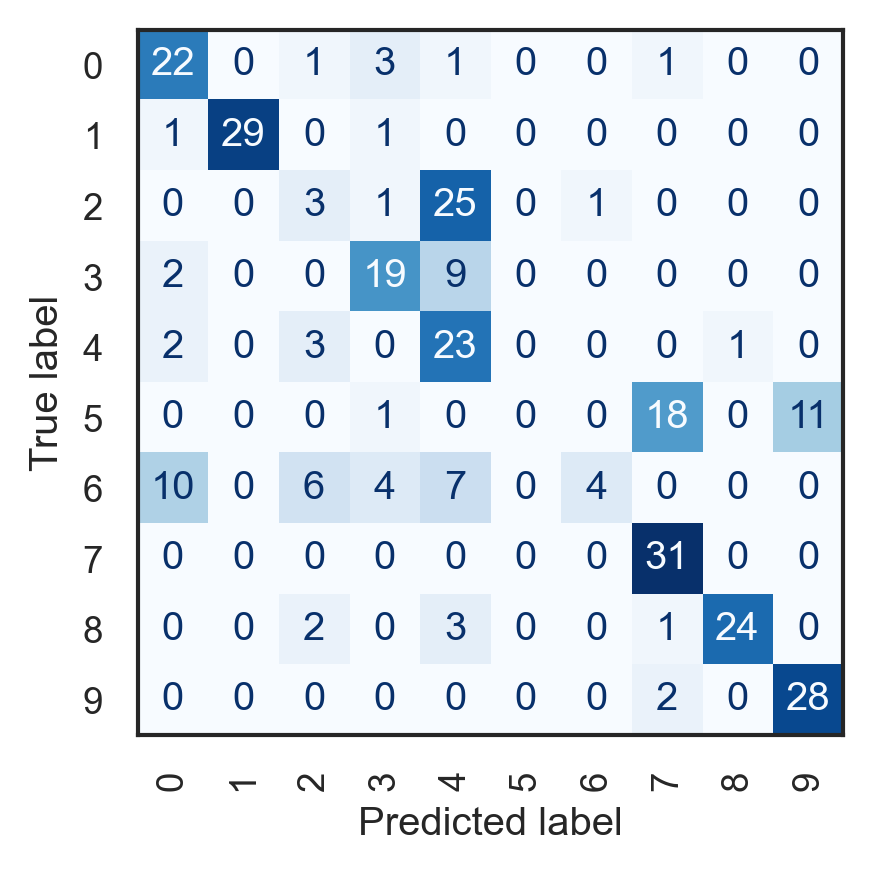

In [21]:
st, y_pred, acc = self_trainedFunction(Z_train,y_labelled,Z_test,y_test,threshold=0.1, max_iter=1,n_neighbors=15)

print(f"Self-training sur UMAP : {acc:.4f}")
print("n_iter_ =", st.n_iter_, "term =", st.termination_condition_)

filename="cnfmatKNNSelftTrng.png"
display_confusionMatrix(y_test,y_pred,num_classes,filename=filename)
from IPython.display import Image, display
display(Image(os.path.join(path, filename), width=300))

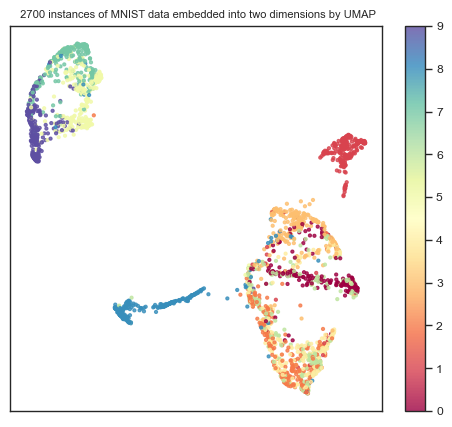

In [22]:
color = np.asarray(y_train, dtype=int)
fig, ax = plt.subplots(figsize=(6, 5))
plt.scatter(Z_train[:, 0], Z_train[:, 1], c=color, cmap="Spectral", s=5, alpha=0.8) # type: ignore
plt.setp(ax, xticks=[], yticks=[])
plt.title(f" {len(Z_train)} instances of MNIST data embedded into two dimensions by UMAP", fontsize=8) # type: ignore
plt.colorbar()
plt.show()

In [23]:
# 1. Modèle + optimizer
del modelbase_KNN
del reducer
del st

import gc
gc.collect()

95718

In [20]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.semi_supervised import LabelPropagation
from sklearn.neighbors import kneighbors_graph
from sklearn.metrics.pairwise import rbf_kernel

def label_prop_function(kernel, X, y, n_neighbors=5, gamma=1.0, max_iter=5000,tol=0.001,flag=False):
    w=[]
    label_prop = LabelPropagation(kernel=kernel,n_neighbors=n_neighbors,
                                  max_iter=max_iter,gamma=gamma,tol=tol)
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=int)
    label_prop.fit(X, y)
    y_propag = label_prop.transduction_

    if kernel == "knn":
        # graphe KNN binaire
        W = kneighbors_graph(X, n_neighbors=n_neighbors,mode="connectivity", include_self=False)
        G = nx.from_scipy_sparse_array(W)
    elif kernel == "rbf":
        # matrice RBF dense
        K = rbf_kernel(X, gamma=gamma)           # K_ij = exp(-gamma ||xi-xj||^2)[web:181][web:183]
        np.fill_diagonal(K, 0.0)                 # pas de boucle i->i
        G = nx.from_numpy_array(K)               # poids = K_ij
        W = K
    else:
        raise ValueError("kernel doit être 'knn' ou 'rbf'")
    if flag:
       print(f"W matrice de similarité RBF symétrique construite avec un noyau gaussien sur les points {X.transpose()}.")
       for i in range(W.shape[0]):
            row = W[i].toarray().ravel() if hasattr(W, "toarray") else W[i]
            print([f"{v:.4f}" for v in row])

    return label_prop,y_propag, W, G

In [24]:
reducer = umap.UMAP(
     n_neighbors=15, n_components=20, metric='euclidean', n_epochs=None, learning_rate=0.2,
     init='spectral', min_dist=0.1, spread=1.0, set_op_mix_ratio=1.0, local_connectivity=1.0, 
     repulsion_strength=1.0, negative_sample_rate=2, transform_queue_size=4.0, a=None, b=None, 
     random_state=None, metric_kwds=None, angular_rp_forest=False, target_n_neighbors=-1,
     target_metric='categorical', target_metric_kwds=None, target_weight=0.0, transform_seed=42, verbose=False)

Z_train = reducer.fit_transform(X_train)
Z_test = reducer.transform(X_test)
# euclidean (par défaut), manhattan, chebyshev, minkowski (avec paramètre p via metric_kwds)


In [26]:
from sklearn.semi_supervised import LabelPropagation
from sklearn.model_selection import GridSearchCV

param_grid = [
    {
        "kernel": ["knn"],
        "n_neighbors": [10, 15, 30],
        "max_iter": [1000, 3000],
        "tol": [1e-3, 1e-4],
    },
]

lp = LabelPropagation()
search = GridSearchCV(lp, param_grid, cv=3, n_jobs=-1)
search.fit(Z_train, y_train)
print(search.best_params_, search.best_score_)

{'kernel': 'knn', 'max_iter': 1000, 'n_neighbors': 10, 'tol': 0.001} 0.7429629629629629


In [36]:
kernel="knn"
n_neighbors=20
# Z_train,y_labelled,Z_test,y_test,
label_prop,y_propag, W, G = label_prop_function(kernel, Z_train,y_labelled,
                            n_neighbors=n_neighbors, gamma=20,max_iter=1000,tol=0.05,flag=False)
y_pred = label_prop.predict(Z_test)
acc = accuracy_score(np.asarray(y_test).astype(int),y_pred)
print("Accuracy %.3f"%acc)

Accuracy 0.640


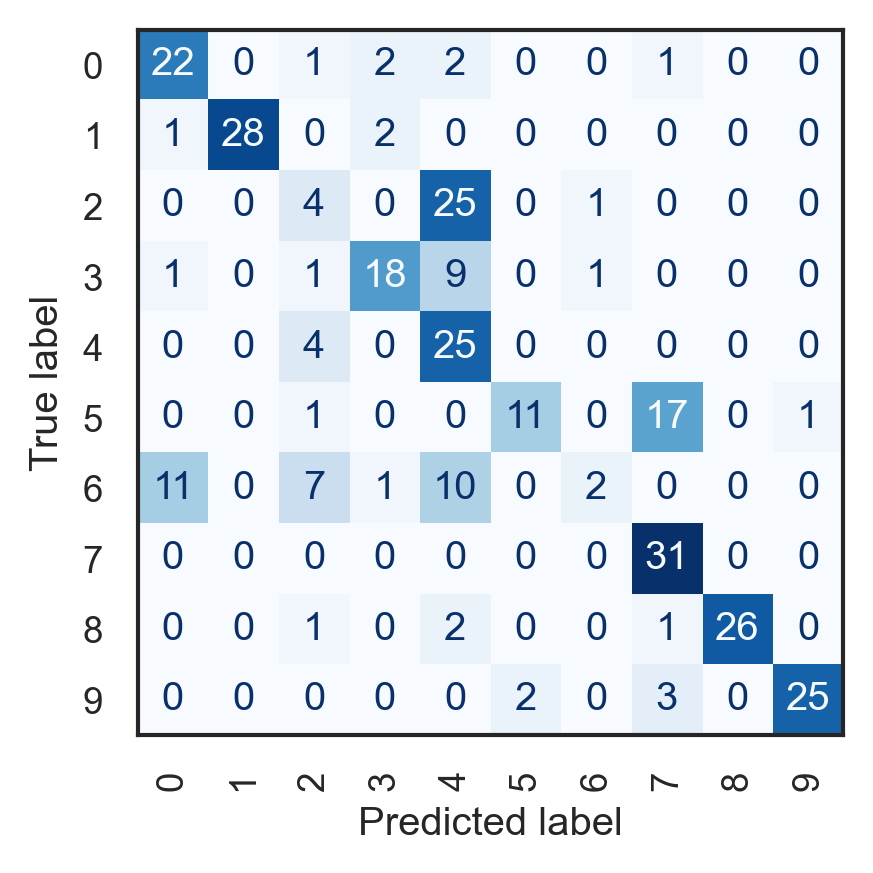

In [37]:
filename="cnfmatlabel_prop.png"
display_confusionMatrix(y_test,y_pred,num_classes,filename=filename)
from IPython.display import Image, display
display(Image(os.path.join(path, filename), width=300))

`LabelPropagation fait des mises à jour itératives des distributions de labels sur le graphe jusqu’à ce que les changements deviennent très faibles (convergence) ou qu’il atteigne max_iter.`
`Ici, au bout de 1000 itérations, le critère « changement < tolérance » n’est pas atteint, donc sklearn s’arrête et émet ConvergenceWarning: max_iter=1000 was reached without convergence.`


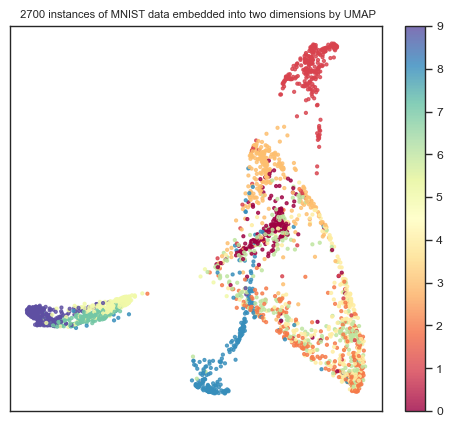

In [38]:
color = np.asarray(y_train, dtype=int)
fig, ax = plt.subplots(figsize=(6, 5))
plt.scatter(Z_train[:, 0], Z_train[:, 1], c=color, cmap="Spectral", s=5, alpha=0.8) # type: ignore
plt.setp(ax, xticks=[], yticks=[])
plt.title(f" {len(Z_train)} instances of MNIST data embedded into two dimensions by UMAP", fontsize=8) # type: ignore
plt.colorbar()
plt.show()

La séparation entre certaines classes reste bonne (par exemple le gros groupe en haut à droite très homogène en couleur, typiquement un chiffre comme 1 ou 0), ce qui confirme que ces digits sont faciles à distinguer dans l’espace de UMAP.
Le gros amas central mélange davantage de couleurs que dans ta version à 63 000 points : avec moins de données, UMAP a moins d’information pour « délimiter » des frontières nettes entre classes proches, donc les triplets de chiffres ambigus se mélangent plus.

## `Version complète MNIST`

In [30]:
subset_ratio = 0.30 # on ne prend pas tout pour aller plus vite
train_ratio = 0.9  # on entraine sur % du subset
labelled_ratio = 0.1 # et on utilise qu'une partie des labels (semi-sup)

subset_size = 10000
X = mnist.data # type: ignore
y = mnist.target # type: ignore

print("nb de dimension de mnist :", X.shape)        # (70000, 784)
print("nb d'exemples :", X.shape[0])
print("dimension     :", X.shape[1])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=0, 
    train_size=train_ratio, 
    test_size=(1-train_ratio)
)
print(f"len train {len(X_train)} len test {len(X_test)}")

nb de dimension de mnist : (70000, 784)
nb d'exemples : 70000
dimension     : 784
len train 63000 len test 7000


In [31]:
labelled_ratio = 0.025 # combien d'exemples avec labels ? -> 
y_labelled = np.copy(y_train) # type: ignore
y_labelled[int(labelled_ratio*len(y_labelled)):] = -1 # type: ignore
num_classes = np.unique(np.asarray(y_labelled, dtype=int), return_counts=True)[0].size - 1

print(f"nombre d'items total {len(y_labelled)}") 
print(f"labellisé : {int(labelled_ratio*len(y_labelled))}") # type: ignore
print(f" unlabellisés {len(y_labelled)-int(labelled_ratio*len(y_labelled))} ") # type: ignore
print(f"nombre de classes {num_classes}")

nombre d'items total 63000
labellisé : 1575
 unlabellisés 61425 
nombre de classes 10


In [32]:
reducer = umap.UMAP(
     n_neighbors=15, n_components=2, metric='euclidean', n_epochs=None, learning_rate=0.2,
     init='spectral', min_dist=0.01, spread=1.0, set_op_mix_ratio=1.0, local_connectivity=1.0, 
     repulsion_strength=1.0, negative_sample_rate=2, transform_queue_size=4.0, a=None, b=None, 
     random_state=None, metric_kwds=None, angular_rp_forest=False, target_n_neighbors=-1,
     target_metric='categorical', target_metric_kwds=None, target_weight=0.0, transform_seed=42, verbose=False)

Z_train = reducer.fit_transform(X_train)
Z_test = reducer.transform(X_test)

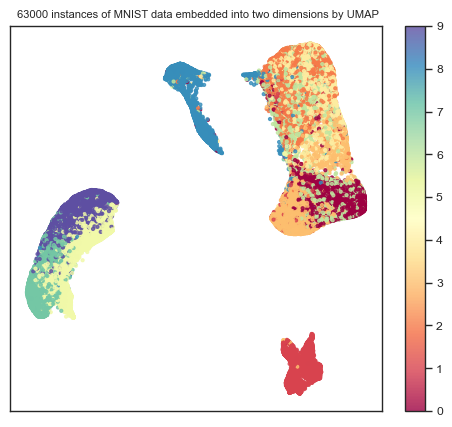

In [33]:
color = np.asarray(y_train, dtype=int)
fig, ax = plt.subplots(figsize=(6, 5))
plt.scatter(Z_train[:, 0], Z_train[:, 1], c=color, cmap="Spectral", s=5, alpha=0.8) # type: ignore
plt.setp(ax, xticks=[], yticks=[])
plt.title(f" {len(Z_train)} instances of MNIST data embedded into two dimensions by UMAP", fontsize=8) # type: ignore
plt.colorbar()
plt.show()

 `En résumé, l'embedding est « raisonnable » :` 
 - Il sépare bien plusieurs chiffres, mais laisse visibles les confusions attendues entre classes morphologiquement proches, ce qui cadre avec ce que l’on observe classiquement avec UMAP sur MNIST.

 - Le gros nuage à gauche mélange plusieurs labels, probablement les classes visuellement proches (3,5,8 / 4,7,9), ce qui est un comportement classique de UMAP sur MNIST.
 - Un amas très allongé et presque mono‑couleur (en haut à droite ou au centre selon ta palette) correspond typiquement au 1, qui est souvent très bien séparé des autres chiffres.
 - Le petit cluster rouge isolé en bas (ou en bas à gauche) est cohérent avec une classe très distinctive (souvent le 0 ou le 9 selon la palette), ce qui montre que certaines classes sont presque parfaitement séparées.

In [34]:
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.semi_supervised import LabelSpreading, LabelPropagation

accuracy 0.7787


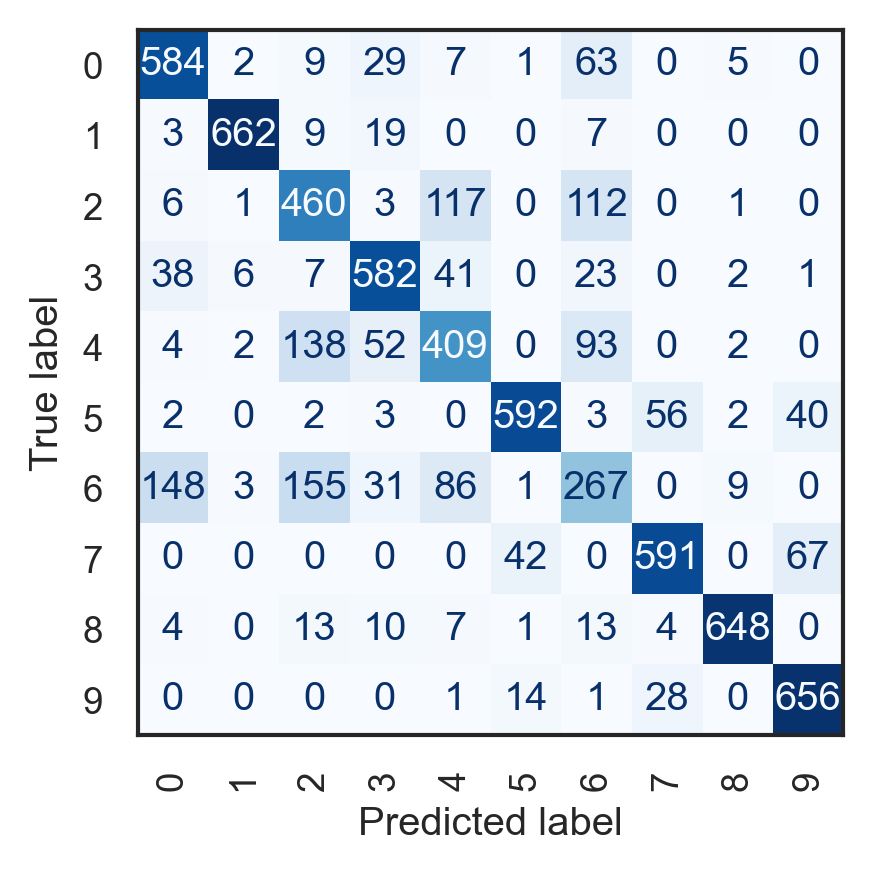

In [35]:
modelbase_KNN, y_pred, acc = self_trainedModel(Z_train,y_train,Z_test,y_test,n_neighbors=15 )

print(f"accuracy {acc:.4f}")
filename="cnfmatKNNSelftTrng.png"
display_confusionMatrix(y_test,y_pred,num_classes,filename=filename)
from IPython.display import Image, display
display(Image(os.path.join(path, filename), width=300))

Self-training sur UMAP : 0.7441
n_iter_ = 1 term = all_labeled


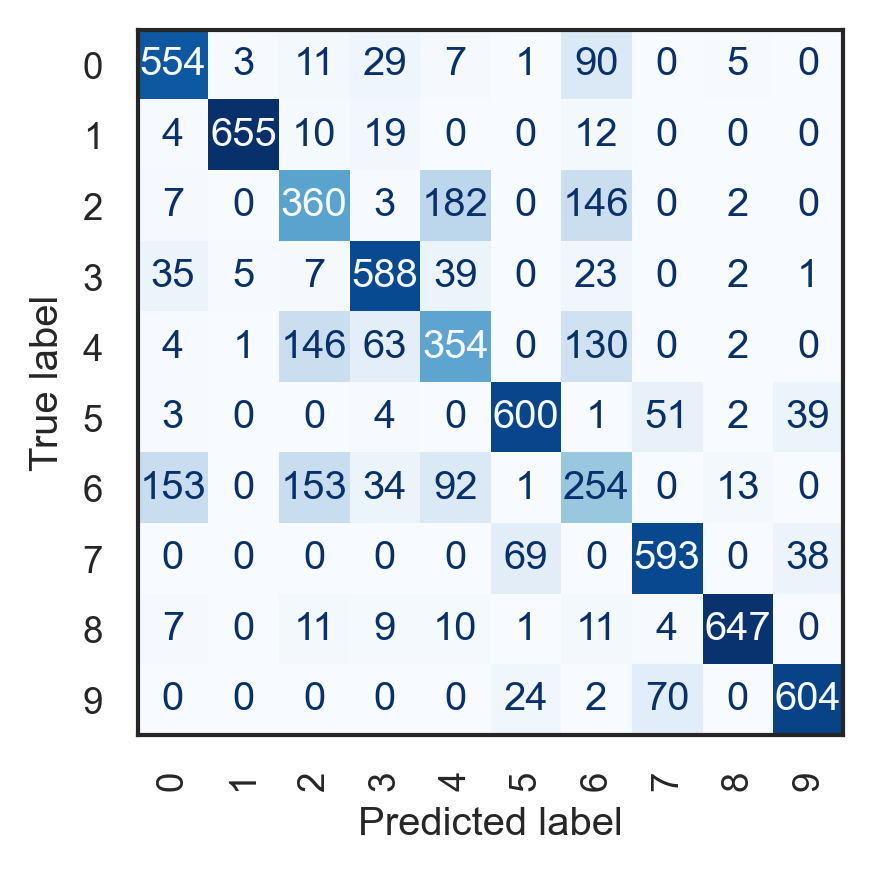

In [36]:
st, y_pred, acc = self_trainedFunction(Z_train,y_labelled,Z_test,y_test,threshold=0.1, max_iter=1,n_neighbors=15)

print(f"Self-training sur UMAP : {acc:.4f}")
print("n_iter_ =", st.n_iter_, "term =", st.termination_condition_)

filename="cnfmatKNNSelftTrng.png"
display_confusionMatrix(y_test,y_pred,num_classes,filename=filename)
from IPython.display import Image, display
display(Image(os.path.join(path, filename), width=300))

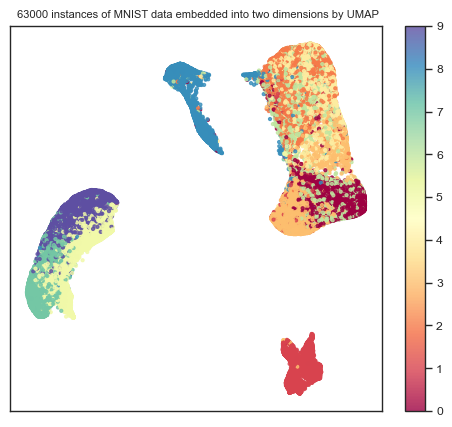

In [37]:
color = np.asarray(y_train, dtype=int)
fig, ax = plt.subplots(figsize=(6, 5))
plt.scatter(Z_train[:, 0], Z_train[:, 1], c=color, cmap="Spectral", s=5, alpha=0.8) # type: ignore
plt.setp(ax, xticks=[], yticks=[])
plt.title(f" {len(Z_train)} instances of MNIST data embedded into two dimensions by UMAP", fontsize=8) # type: ignore
plt.colorbar()
plt.show()

### __`Comparaison avec TSNE`__
t‑SNE est une méthode de réduction de dimension non linéaire conçue surtout pour la visualisation (2D/3D) de données de grande dimension en préservant les voisinages locaux.

__Idée de base__
- En haute dimension, t‑SNE modélise la similarité entre deux points $x_i,x_j$ par une probabilité $p_ij$ obtenue à partir d’un noyau gaussien centré sur chaque point (la largeur du noyau est réglée par la perplexity).
- En basse dimension, il cherche des points $y_i ,y_j$ et définit des probabilités $q_ij$ avec une loi de Student à 1 degré de liberté (t‑distribution), qui a des queues lourdes et aide à résoudre le « crowding problem »

__Propriétés pratiques__
 - t‑SNE est très bon pour faire apparaître des clusters locaux (groupes d’objets similaires) et des sous‑structures fines, mais les distances entre clusters et la géométrie globale ne sont pas interprétables.
 - L’algorithme est stochastique, la fonction coût n’est pas convexe, donc deux runs avec seeds différents peuvent donner des embeddings globalement similaires mais tournés/étirés différemment.

In [38]:
%time embedTSNE = TSNE(n_components=2).fit_transform(mnist.data)

CPU times: user 15min 12s, sys: 21.6 s, total: 15min 33s
Wall time: 3min 1s


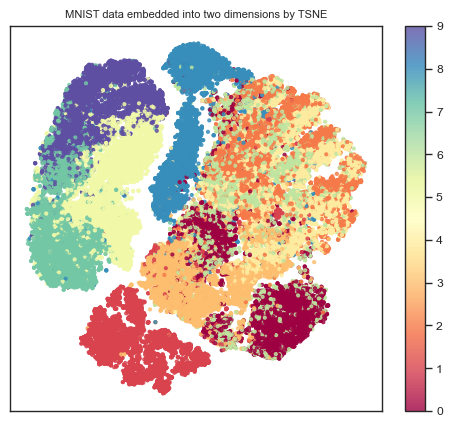

In [39]:
color = mnist.target.astype(int) # type: ignore
fig, ax = plt.subplots(figsize=(6, 5))
plt.scatter(embedTSNE[:, 0], embedTSNE[:, 1], c=color, cmap="Spectral", s=5, alpha=0.8) # type: ignore
plt.setp(ax, xticks=[], yticks=[])
plt.title("MNIST data embedded into two dimensions by TSNE", fontsize=8)
plt.colorbar()
plt.show()

__`t‑SNE est transductif :`__ 
 - l’embedding dépend globalement de l’ensemble des points, 
 - on ne sait pas appliquer exactement la même transformation à de nouveaux points sans tout ré‑optimiser.
 - L’API sklearn explicite ça en n’exposant que fit et fit_transform, 
 - L'API déconseille l’usage de t‑SNE dans un pipeline classique train/test.

In [40]:
X_all = np.vstack([X_train, X_test])
Z_all = TSNE(n_components=2, random_state=0).fit_transform(X_all)
Z_train = Z_all[:len(X_train)]
Z_test  = Z_all[len(X_train):]

accuracy 0.8426


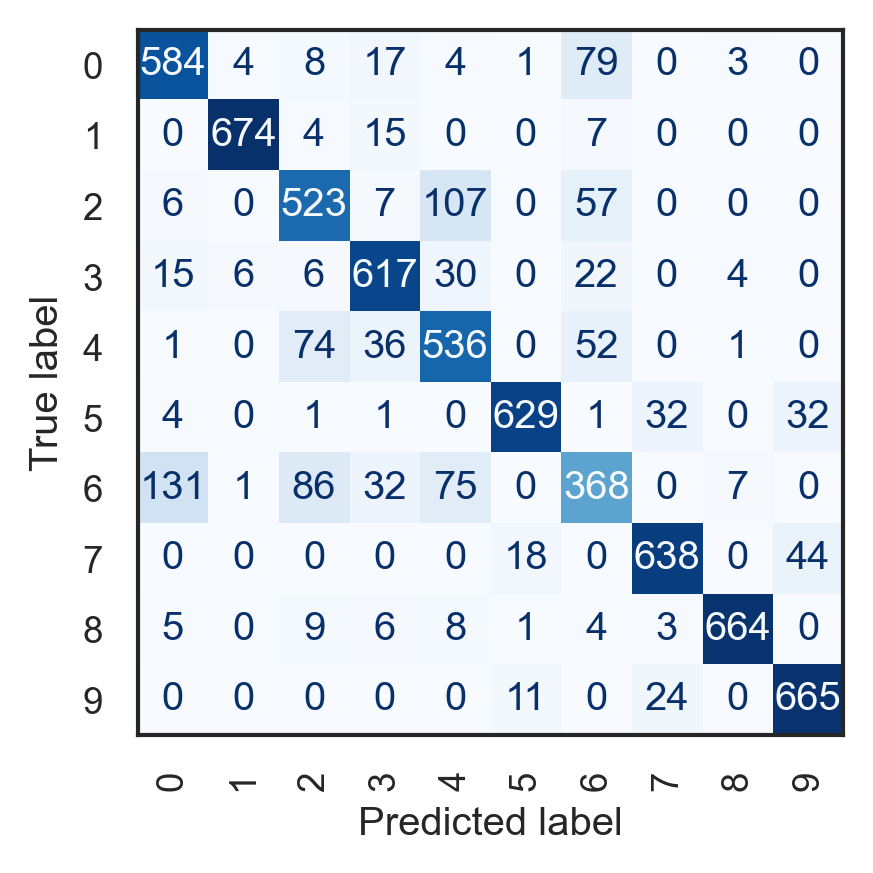

In [41]:
modelbase_KNN, y_pred, acc = self_trainedModel(Z_train,y_train,Z_test,y_test,n_neighbors=15 )

print(f"accuracy {acc:.4f}")
filename="cnfmatKNNSelftTrng.png"
display_confusionMatrix(y_test,y_pred,num_classes,filename=filename)
from IPython.display import Image, display
display(Image(os.path.join(path, filename), width=300))

Self-training sur UMAP : 0.7841
n_iter_ = 1 term = all_labeled


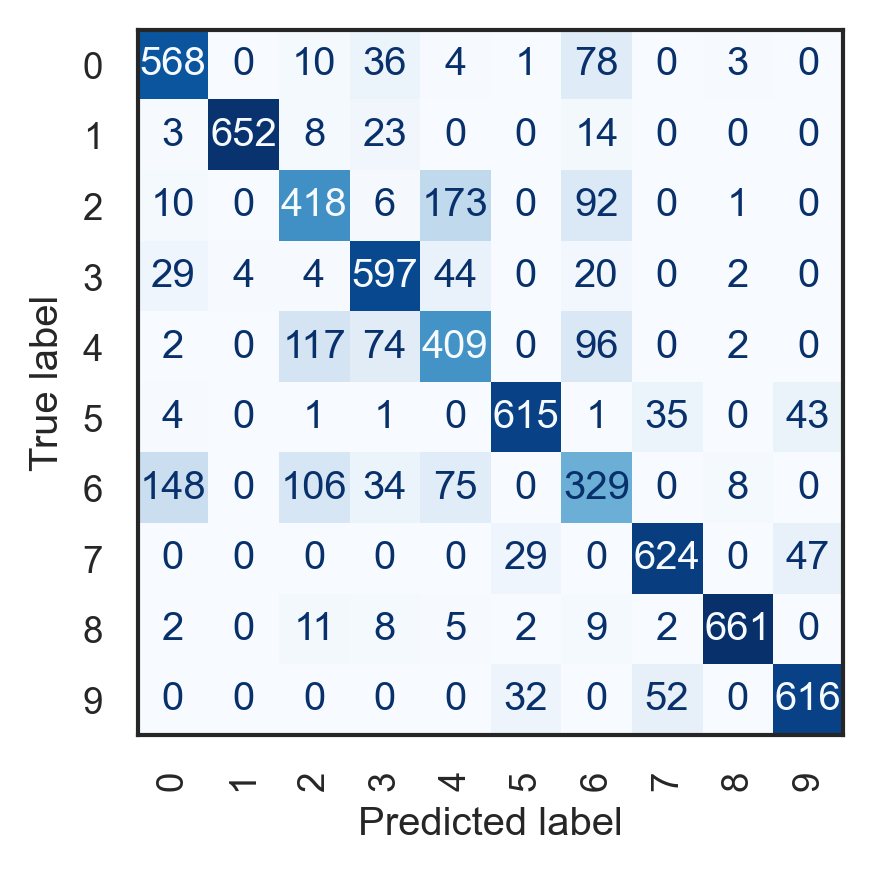

In [42]:
st, y_pred, acc = self_trainedFunction(Z_train,y_labelled,Z_test,y_test,threshold=0.1, max_iter=1,n_neighbors=15)

print(f"Self-training sur UMAP : {acc:.4f}")
print("n_iter_ =", st.n_iter_, "term =", st.termination_condition_)

filename="cnfmatKNNSelftTrng.png"
display_confusionMatrix(y_test,y_pred,num_classes,filename=filename)
from IPython.display import Image, display
display(Image(os.path.join(path, filename), width=300))

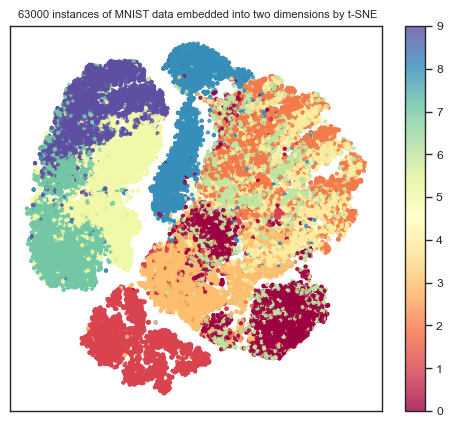

In [43]:
color = np.asarray(y_train, dtype=int)
fig, ax = plt.subplots(figsize=(6, 5))
plt.scatter(Z_train[:, 0], Z_train[:, 1], c=color, cmap="Spectral", s=5, alpha=0.8) # type: ignore
plt.setp(ax, xticks=[], yticks=[])
plt.title(f" {len(Z_train)} instances of MNIST data embedded into two dimensions by t-SNE", fontsize=8) # type: ignore
plt.colorbar()
plt.show()